# Part 1. Intersections of right lifting classes of morphisms whose codomains are transitive.

There are 6 primordial classes, $\mathsf{inj}^e, \mathsf{inj}^{C_p}, \mathsf{surj}^e, \mathsf{surj}^{C_p}, \mathsf{pb},$ and $\mathsf{homog}$. We record their names in `primordial_classes`. `original_relations_primordial` records pairs $(S,T)$ where $S$ and $T$ are subsets of $\{0,\dots,n-1\}$ such that $S \nsupseteq T$ and $\bigcap_{s \in S} \text{primordial\_classes}_s \subseteq \bigcap_{t \in T} \text{primordial\_classes}_t$. We will check later that every containment between intersections of primordial classes is a formal consequence of those recorded in `original_relations_primordial`.

In [1]:
primordial_classes = ["\\inj^e", "\\inj^{C_p}", "\\surj^e", "\\surj^{C_p}", "\\pb", "\\homog"]
n_primordial = len(primordial_classes)
original_relations_primordial = [
    ({0}, {1}),
    ({0}, {4}),
    ({0}, {5}),
    ({4}, {5}),
    ({0, 2}, {1}),
    ({0, 2}, {3}),
    ({0, 2}, {4}),
    ({0, 2}, {5}),
    ({2, 4}, {3}),
    ({3, 5}, {4}),
]

`reduce` takes a subset `x_orig` of $\{0, \dots, n-1\}$ and a list of relations (`original_relations_primordial`) and produces the *maximal* subset whose intersection agrees with `x_orig`. In other words, `reduce` produces canonical representatives of elements in the meet-semilattice generated by the primordial classes under intersection.

In [2]:
def reduce(x_orig, rels):
    x = x_orig.copy()
    changed = True
    while changed:
        changed = False
        for r in rels:
            if r[0].issubset(x) and not r[1].issubset(x):
                x |= r[1]
                changed = True
    return x

We now use `reduce` to produce the elements of this meet-semilattice. We store these elements in a dictionary `primordial_intersections` whose keys are the canonical representatives (produced by `reduce`, stored to tuples so they're hashable) and whose values the list of intersections (subsets of $\{0, \dots, n-1\}$) with the same canonical representative.

In [3]:
naive_primordial_intersections = [set(s) for s in subsets(range(n_primordial))]
primordial_intersections = dict()

for el1 in naive_primordial_intersections:
    reduced_el1 = reduce(el1, original_relations_primordial)
    key = tuple(sorted(reduced_el1))
    if key not in primordial_intersections:
        primordial_intersections[key] = []
    primordial_intersections[key].append(el1)

`n_primordial_intersections` is the number of elements in this meet-semilattice. `primordial_intersections_list` is the list of equivalence classes (the values of the dictionary `primordial_intersections`). One primordial interseciton $S$ is contained in another $T$ if there is a representative $S'$ of the equivalence class of $S$ and a representative $T'$ of the equivalence class of $T$ such that $T' \subseteq S'$ (an intersection of fewer things is a larger set). From this we produce the poset `primordial_intersections_poset`. Using the constructor `MeetSemilattice` forces Sage to check that this is indeed a meet-semilattice.

In [4]:
n_primordial_intersections = len(primordial_intersections)
primordial_intersections_list = list(primordial_intersections.values())

def set_to_index_primordial(s):
    return next(i for i,l in enumerate(primordial_intersections_list) if s in l)

primordial_intersections_edges = [(x,y) for x in range(n_primordial_intersections) for y in range(n_primordial_intersections) if any([z.issubset(w) for z in primordial_intersections_list[y] for w in primordial_intersections_list[x]])]

primordial_intersections_poset = MeetSemilattice([range(n_primordial_intersections), primordial_intersections_edges])

`primordial_intersection_names` stores a human-readable (TeX) name for each element of the poset.

In [6]:
primordial_intersection_names = {k: " \\cap ".join([primordial_classes[i] for i in min(primordial_intersections_list[k])]) if primordial_intersections_list[k][0] else "\\all" for k in range(n_primordial_intersections)}

The following code block displays the primordial intersection poset and prints the code for a tikzpicture of the poset. This is Figure 2 in the paper.

\begin{tikzpicture}[scale=2.5]
\node[rectangle,thick,draw] (0) at (0, 6) {0: $\all$};
\node[rectangle,thick,draw] (1) at (-4, 2) {1: $\inj^e$};
\node[rectangle,thick,draw] (2) at (-1, 5) {2: $\inj^{C_p}$};
\node[rectangle,thick,draw] (3) at (-3, 4) {3: $\surj^e$};
\node[rectangle,thick,draw] (4) at (0, 0) {4: $\inj^e \cap \surj^e$};
\node[rectangle,thick,draw] (5) at (-5, 3) {5: $\inj^{C_p} \cap \surj^e$};
\node[rectangle,thick,draw] (6) at (-1, 4) {6: $\surj^{C_p}$};
\node[rectangle,thick,draw] (7) at (-1, 1) {7: $\inj^e \cap \surj^{C_p}$};
\node[rectangle,thick,draw] (8) at (-3, 3) {8: $\inj^{C_p} \cap \surj^{C_p}$};
\node[rectangle,thick,draw] (9) at (-1, 3) {9: $\surj^e \cap \surj^{C_p}$};
\node[rectangle,thick,draw] (10) at (-2, 2) {10: $\inj^{C_p} \cap \surj^e \cap \surj^{C_p}$};
\node[rectangle,thick,draw] (11) at (1, 4) {11: $\pb$};
\node[rectangle,thick,draw] (12) at (1, 3) {12: $\inj^{C_p} \cap \pb$};
\node[rectangle,thick,draw] (13) at (0, 2) {13: $\surj^e \cap \pb$};
\node[

Matplotlib is building the font cache; this may take a moment.


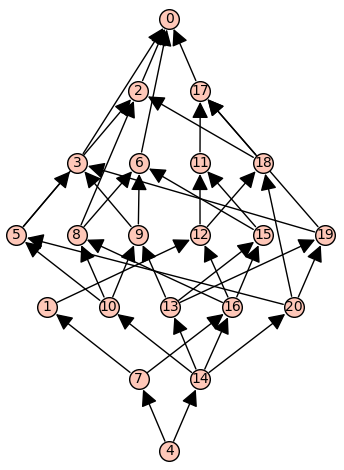

In [10]:
cov_rels = primordial_intersections_poset.cover_relations()
heights = {k : 0 for k in range(n_primordial_intersections)}

changed = True
while changed:
    changed = False
    for (a,b) in cov_rels:
        if heights[b] <= heights[a]:
            heights[b] = heights[a] + 1
            changed = True

max_height = max(heights.values())

of_height = {k : [i for i in range(n_primordial_intersections) if heights[i] == k] for k in set(heights.values())}

coords = dict()
for h in range(max_height + 1):
    level = of_height[h]
    width = len(level)
    for i, k in enumerate(level):
        coords[k] = (2*i - width + 1, h)

print("\\begin{tikzpicture}[scale=2.5]")

for k in range(n_primordial_intersections):
    print(f"\\node[rectangle,thick,draw] ({k}) at {coords[k]} {{{k}: ${primordial_intersection_names[k]}$}};")

for (a,b) in cov_rels:
	print(f"\\draw[thick,->] ({a}) -- ({b});")

print("\\end{tikzpicture}")

primordial_intersections_poset.plot()

We must also check that the non-containments recorded in this poset here are correct, i.e. that every containment between intersections of primordial classes is a formal consequence of those recorded in `original_relations_primordial`. It suffices to check that each element $X$ of the meet-semilattice we produced is not contained in any primordial class $y$ except those for which the containment $X \subseteq y$ appears in the meet-semilattice. Then, for any $Y = \bigcap_{i} y_i$ we have $X \subseteq Y$ if and only if $X \subseteq y_i$ for all $i$. The following code block produces a list of things to check; these checks are performed in Appendix A.1.

In [8]:
for k in range(n_primordial_intersections):
    for i in range(n_primordial):
        if len(min(primordial_intersections_list[k])) > 1 and not primordial_intersections_poset.le(k, set_to_index_primordial({i})):
            print(f"\\subsection*{{${primordial_intersection_names[k]} \\nsubseteq {primordial_classes[i]}$}}")

\subsection*{$\inj^{C_p} \cap \surj^e \nsubseteq \inj^e$}
\subsection*{$\inj^{C_p} \cap \surj^e \nsubseteq \surj^{C_p}$}
\subsection*{$\inj^{C_p} \cap \surj^e \nsubseteq \pb$}
\subsection*{$\inj^{C_p} \cap \surj^e \nsubseteq \homog$}
\subsection*{$\inj^e \cap \surj^{C_p} \nsubseteq \surj^e$}
\subsection*{$\inj^{C_p} \cap \surj^{C_p} \nsubseteq \inj^e$}
\subsection*{$\inj^{C_p} \cap \surj^{C_p} \nsubseteq \surj^e$}
\subsection*{$\inj^{C_p} \cap \surj^{C_p} \nsubseteq \pb$}
\subsection*{$\inj^{C_p} \cap \surj^{C_p} \nsubseteq \homog$}
\subsection*{$\surj^e \cap \surj^{C_p} \nsubseteq \inj^e$}
\subsection*{$\surj^e \cap \surj^{C_p} \nsubseteq \inj^{C_p}$}
\subsection*{$\surj^e \cap \surj^{C_p} \nsubseteq \pb$}
\subsection*{$\surj^e \cap \surj^{C_p} \nsubseteq \homog$}
\subsection*{$\inj^{C_p} \cap \surj^e \cap \surj^{C_p} \nsubseteq \inj^e$}
\subsection*{$\inj^{C_p} \cap \surj^e \cap \surj^{C_p} \nsubseteq \pb$}
\subsection*{$\inj^{C_p} \cap \surj^e \cap \surj^{C_p} \nsubseteq \homog$}
\s

# Part 2: Right lifting classes of single morphisms

There are 5 vacuous lifting classes of morphisms with transitive codomains: $\{\operatorname{id}_\varnothing\}, \mathsf{init}^e, \{\operatorname{id}_\varnothing\}^{C_p}, \mathsf{init}^{C_p} \cap \mathsf{pb},$ and $\mathsf{init}^{C_p}$. We record their names in `vac_classes`. `vac_poset` is the join-semilattice (w.r.t. $\cup$) generated by these classes -- there is only one nontrivial join (Figure 1). `vac_poset_map` is a list such that `vac_poset_map[i]` is the set of indices $J$ such that the $i$​th element of `vac_poset` is $\bigcup_{j \in J} \text{vac\_classes}_j$.

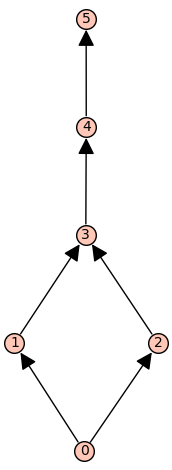

In [13]:
vac_classes = ["\\{\\id_\\varnothing\\}", "\\init^e", "\\{\\id_\\varnothing\\}^{C_p}", "(\\init^{C_p} \\cap \\pb)", "\\init^{C_p}"]

vac_poset = JoinSemilattice({0: [1,2,3,4,5], 1:[3,4,5], 2:[3,4,5], 3:[4,5], 4:[5], 5:[]})

vac_poset_map = [{0}, {1}, {2}, {1,2}, {3}, {4}]

vac_poset_labels = [" \\cup ".join(vac_classes[i] for i in s) for s in vac_poset_map]

vac_poset.plot()

Each morphism with transitive codomain has a right lifting class and a vacuous lifting class. The possible pairs `(i,j)` that can be produced are recorded in the list `rows_from_tables` where  `i` is an index into `vac_poset` and `j` is an index into `primordial_intersections_list`. These pairs come from Tables 2 and 3.

In [11]:
rows_from_tables = [
    ("\\nabla_{e,0}", 0, set_to_index_primordial({2})),
    ("\\nabla_{e,1}", 1, set_to_index_primordial(set())),
    ("\\nabla_{e,>1}", 1, set_to_index_primordial({0})),
    ("(n=0,m=0)", 2, set_to_index_primordial({3})),
    ("(n=0,m=1)", 5, set_to_index_primordial(set())),
    ("(n=0,m>1)", 5, set_to_index_primordial({1})),
    ("(n=1,m=0)", 4, set_to_index_primordial({4})),
    ("(n>1,m=0)", 4, set_to_index_primordial({1,4})),
    ("(n>=1,m>=1)", 5, set_to_index_primordial({1,5}))
]

`vac_rl_containment` determines if an element of `vac_poset` is contained in an element of `primordial_intersections_poset`. This is determined by querying the matrix `containment_matrix`, which is Table 5 in the paper.

In [14]:
# vac_class is an integer in 0..5
# rl_class is a subset of 0..5
def vac_rl_containment(vac_class, rl_class):
    # containment_matrix[i][j] iff vac_poset_map[i] is contained in primordial_classes[j]
    containment_matrix = [
        [True, True, True, True, True, True],
        [True, True, False, False, True, True],
        [False, True, False, True, True, True],
        [False, True, False, False, True, True],
        [False, True, False, False, True, True],
        [False, True, False, False, False, True]
    ]
    return all(containment_matrix[vac_class][i] for i in rl_class)

The right lifting class of a single morphism $f = \coprod_i f_i$ is of the form $\bigcup_i \{f_i\}^\varnothing \cup \bigcap_i \{f\}^{\diagup\!\!\!\!\square}$. We store these classes in `singleton_rl_classes` as pairs `(A,A')` where `A` is an element of `primordial_intersections_list` (representing $\bigcap_i \{f\}^{\diagup\!\!\!\!\square}$) and `A'` is an index into `vac_poset` (representing $\bigcup_i \{f_i\}^\varnothing$).

In [16]:
# Determines if one singleton right-lifting class is contained in another, according to Lemma 5.14.
def singleton_rl_class_containment(srl_class_1, srl_class_2):
    return primordial_intersections_poset.le(srl_class_1[0], srl_class_2[0]) and (vac_poset.le(srl_class_1[1], srl_class_2[1]) or vac_rl_containment(srl_class_1[1], primordial_intersections_list[srl_class_2[0]][0]))

# Determines if two singleton right-lifting classes are equal, by checking containment both ways.
def singleton_rl_class_eq(srl_class_1, srl_class_2):
    return singleton_rl_class_containment(srl_class_1, srl_class_2) and singleton_rl_class_containment(srl_class_2, srl_class_1)

singleton_rl_classes_list = list()
# Every singleton right-lifting class comes from a subset of the table rows in `rows_from_tables`.
for selection in subsets(rows_from_tables):
    join_of_vac_classes = vac_poset.join([s[1] for s in selection])
    meet_of_rl_classes = primordial_intersections_poset.meet([s[2] for s in selection])
    new_pair = (meet_of_rl_classes, join_of_vac_classes)
    existing_equiv_class = next((l for l in singleton_rl_classes_list if singleton_rl_class_eq(new_pair,l[0])), None)
    if existing_equiv_class is not None:
        existing_equiv_class.append(new_pair)
    else:
        singleton_rl_classes_list.append([new_pair])

n_singleton_rl_classes = len(singleton_rl_classes_list)

singleton_rl_classes_canonical = list()
# Generate canonical names for the singleton right-lifting classes by making a minimal choice of (A,A') in each equivalence class.
for l in singleton_rl_classes_list:
    for pair1 in l:
        use = True
        for pair2 in l:
            if pair1 == pair2:
                continue
            if primordial_intersections_poset.le(pair2[0], pair1[0]) and vac_poset.le(pair2[1], pair1[1]):
                use = False
                break
        if use:
            singleton_rl_classes_canonical.append(pair1)
            break

singleton_rl_class_names = [f"({primordial_intersection_names[k[0]]}) \\cup {vac_poset_labels[k[1]]}" for k in singleton_rl_classes_canonical]

We now produce the poset of singleton right-lifting classes.

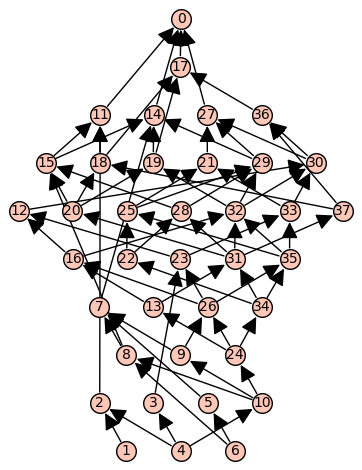

In [18]:
singleton_rl_classes_poset = Poset((range(n_singleton_rl_classes), lambda i,j: singleton_rl_class_containment(singleton_rl_classes_canonical[i], singleton_rl_classes_canonical[j])))

singleton_rl_classes_poset.plot()

The following code block prints the code for a tikzpicture of the poset of singleton right-lifting classes. This is Figure 3 in the paper.

In [19]:
cov_rels = singleton_rl_classes_poset.cover_relations()
heights = {k : 0 for k in range(n_singleton_rl_classes)}

changed = True
while changed:
    changed = False
    for (a,b) in cov_rels:
        if heights[b] <= heights[a]:
            heights[b] = heights[a] + 1
            changed = True

max_height = max(heights.values())

of_height = {k : [i for i in range(n_singleton_rl_classes) if heights[i] == k] for k in set(heights.values())}

coords = dict()
for h in range(max_height + 1):
    level = of_height[h]
    width = len(level)
    for i, k in enumerate(level):
        coords[k] = (2*i - width + 1, h)

print("\\begin{tikzpicture}[scale=2.5]")

for k,name in enumerate(singleton_rl_class_names):
    print(f"\\node[rectangle,thick,draw] ({k}) at {coords[k]} {{{k}: ${name}$}};")

for (a,b) in cov_rels:
	print(f"\\draw[thick,->] ({a}) -- ({b});")

print("\\end{tikzpicture}")

\begin{tikzpicture}[scale=2.5]
\node[rectangle,thick,draw] (0) at (0, 9) {0: $(\all) \cup \{\id_\varnothing\}$};
\node[rectangle,thick,draw] (1) at (-2, 0) {1: $(\surj^e) \cup \{\id_\varnothing\}$};
\node[rectangle,thick,draw] (2) at (-3, 1) {2: $(\surj^e) \cup \init^e$};
\node[rectangle,thick,draw] (3) at (-1, 1) {3: $(\inj^e) \cup \init^e$};
\node[rectangle,thick,draw] (4) at (0, 0) {4: $(\inj^e \cap \surj^e) \cup \init^e$};
\node[rectangle,thick,draw] (5) at (1, 1) {5: $(\surj^{C_p}) \cup \{\id_\varnothing\}^{C_p}$};
\node[rectangle,thick,draw] (6) at (2, 0) {6: $(\surj^e \cap \surj^{C_p}) \cup \{\id_\varnothing\}^{C_p}$};
\node[rectangle,thick,draw] (7) at (-3, 3) {7: $(\surj^{C_p}) \cup \init^e \cup \{\id_\varnothing\}^{C_p}$};
\node[rectangle,thick,draw] (8) at (-2, 2) {8: $(\surj^e \cap \surj^{C_p}) \cup \init^e \cup \{\id_\varnothing\}^{C_p}$};
\node[rectangle,thick,draw] (9) at (0, 2) {9: $(\inj^e \cap \surj^{C_p}) \cup \init^e \cup \{\id_\varnothing\}^{C_p}$};
\node[rectangle

# Part 3: Arbitrary right lifting classes

An arbitrary right lifting class will be an intersection of right lifting classes of single morphisms. These have the form

$$A \cup Q$$

where $A$ is a class appearing in `primordial_intersections_poset` and $Q$ is an intersection of two classes from `primordial_intersections_poset` or `vac_poset`, with at least one coming from `vac_poset`. So, we first compute the poset of such classes $Q$, which we call "mixed classes". The set of mixed classes is computed in Table 7.

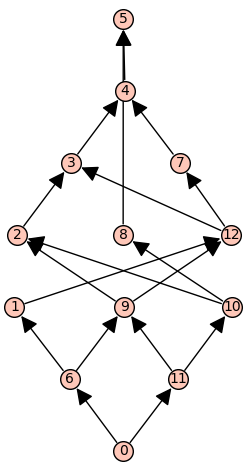

In [23]:
mixed_classes = vac_poset_labels + ["(\\{\\id_\\varnothing\\}^{C_p} \\cap \\init^e)", "(\\init^{C_p} \\cap \\inj^e)", "(\\init^{C_p} \\cap \\surj^e)", "(\\{\\id_\\varnothing\\}^{C_p} \\cap \\inj^e)", "(\\{\\id_\\varnothing\\}^{C_p} \\cap \\surj^e)", "(\\{\\id_\\varnothing\\}^{C_p} \\cap \\bij^e)", "((\\init^e \\cup \\{\\id_\\varnothing\\}^{C_p}) \\cap \\inj^e)"]

n_mixed_classes = len(mixed_classes)

mixed_classes_poset = MeetSemilattice({0: [1,2,3,4,5,6,7,8,9,10,11,12], 1: [12], 2: [3], 3: [4], 4: [5], 5: [], 6: [2,1,9], 7: [4], 8: [5], 9: [2,7,12], 10: [2,8], 11: [9,10], 12: [3, 7]})
mixed_classes_poset.plot()

The following code block prints the code for a tikzpicture of the poset of mixed classes. This is Figure 4 in the paper.

In [24]:
cov_rels = mixed_classes_poset.cover_relations()
heights = {k : 0 for k in range(n_mixed_classes)}

changed = True
while changed:
    changed = False
    for (a,b) in cov_rels:
        if heights[b] <= heights[a]:
            heights[b] = heights[a] + 1
            changed = True

max_height = max(heights.values())

of_height = {k : [i for i in range(n_mixed_classes) if heights[i] == k] for k in set(heights.values())}
coords = dict()
for h in range(max_height + 1):
    level = of_height[h]
    width = len(level)
    for i, k in enumerate(level):
        coords[k] = (2*i - width + 1, h)

print("\\begin{tikzpicture}[scale=2.5]")

for k,name in enumerate(mixed_classes):
    print(f"\\node[rectangle,thick,draw] ({k}) at {coords[k]} {{{k}: ${name}$}};")

for (a,b) in cov_rels:
	print(f"\\draw[thick,->] ({a}) -- ({b});")

print("\\end{tikzpicture}")

\begin{tikzpicture}[scale=2.5]
\node[rectangle,thick,draw] (0) at (0, 0) {0: $\{\id_\varnothing\}$};
\node[rectangle,thick,draw] (1) at (-2, 2) {1: $\init^e$};
\node[rectangle,thick,draw] (2) at (-2, 3) {2: $\{\id_\varnothing\}^{C_p}$};
\node[rectangle,thick,draw] (3) at (-1, 4) {3: $\init^e \cup \{\id_\varnothing\}^{C_p}$};
\node[rectangle,thick,draw] (4) at (0, 5) {4: $(\init^{C_p} \cap \pb)$};
\node[rectangle,thick,draw] (5) at (0, 6) {5: $\init^{C_p}$};
\node[rectangle,thick,draw] (6) at (-1, 1) {6: $(\{\id_\varnothing\}^{C_p} \cap \init^e)$};
\node[rectangle,thick,draw] (7) at (1, 4) {7: $(\init^{C_p} \cap \inj^e)$};
\node[rectangle,thick,draw] (8) at (0, 3) {8: $(\init^{C_p} \cap \surj^e)$};
\node[rectangle,thick,draw] (9) at (0, 2) {9: $(\{\id_\varnothing\}^{C_p} \cap \inj^e)$};
\node[rectangle,thick,draw] (10) at (2, 2) {10: $(\{\id_\varnothing\}^{C_p} \cap \surj^e)$};
\node[rectangle,thick,draw] (11) at (1, 1) {11: $(\{\id_\varnothing\}^{C_p} \cap \bij^e)$};
\node[rectangle,th

Since the set of mixed classes is formed by closing the set of vacuous lifting classes under intersections with primordinal classes, intersection gives a binary operation which takes a mixed class and a primordial class and returns a mixed class. This binary operation is encoded by `mixed_class_absorb_op`, i.e. `mixed_class_absorb_op[i][j]` is the index into `mixed_classes` of the intersection of `mixed_classes[i]` with `primordial_classes[j]`.

In [29]:
mixed_class_absorb_op = [
    [0, 0, 0, 0, 0, 0],#0
    [1, 1, 0, 6, 1, 1],#1
    [9, 2, 10, 2, 2, 2],#2
    [12, 3, 10, 2, 3, 3],#3
    [7, 4, 10, 2, 4, 4],#4
    [7, 5, 8, 2, 4, 5],#5
    [6, 6, 0, 6, 6, 6],#6
    [7, 7, 11, 9, 7, 7],#7
    [11, 8, 8, 10, 10, 8],#8
    [9, 9, 11, 9, 9, 9],#9
    [11, 10, 10, 10, 10, 10],#10
    [11, 11, 11, 11, 11, 11],#11
    [12, 12, 11, 9, 12, 12]#12
]

We encode a general right lifting class as a pair $(i,J)$ where $i$ is an index into `primordial_intersections` and $J$ is a downward-closed set of indices into `mixed_classes`. This represents the right-lifting class $$\underbrace{\text{primordial\_intersections}_i}_A \cup \underbrace{\bigcup_{j \in J} \text{mixed\_classes}_j}_Q.$$ Since arbitrary right-lifting classes are intersections of singleton right-lifting classes, we first implement a procedure `intersect_pair_with_singleton_rl_class` for intersecting and arbitrary right-lifting class with a singleton right-lifting class.

In [30]:
# pair is (i,J) as above, representing A \cup Q
# singleton_rl_class is (k,B') with k an index into `primordial_intersections_poset`, representing B \cup B'
def intersect_pair_with_singleton_rl_class(pair, singleton_rl_class):
    # First, intersect the intersections of primordial classes, i.e. A \cap B
    new_primordial_index = primordial_intersections_poset.meet(pair[0], singleton_rl_class[0])
    # Next, we compute B' \cap A by absorbing the primordial classes of A into B'
    b_prime_cap_a = singleton_rl_class[1]
    for i in min(primordial_intersections_list[pair[0]]):
        b_prime_cap_a = mixed_class_absorb_op[b_prime_cap_a][i]
    # Next, we compute Q \cap B by absorbing the primordial classes of B into Q
    q_cap_b = list(pair[1])
    for j in min(primordial_intersections_list[singleton_rl_class[0]]):
        for i, qi_cap_b in enumerate(q_cap_b):
            q_cap_b[i] = mixed_class_absorb_op[qi_cap_b][j]
    # Finally, we compute Q \cap B' in the meet-semilattice of mixed classes
    q_cap_b_prime = list(pair[1])
    for i, qi_cap_b_prime in enumerate(q_cap_b_prime):
        q_cap_b_prime[i] = mixed_classes_poset.meet(qi_cap_b_prime, singleton_rl_class[1])
    # We must take the downward closure at the end!
    new_set = set(mixed_classes_poset.order_ideal([b_prime_cap_a] + q_cap_b + q_cap_b_prime))
    return (new_primordial_index, new_set)

In [31]:
# We now iteratively compute all right-lifting classes by intersecting singleton right-lifting classes with existing right-lifting classes.
# We start with the empty intersection of singleton right lifting classes, which is (\all, all mixed classes)
right_lifting_classes = [(0, set(range(n_mixed_classes)))]

# now loop over all singleton_rl_classes and intersect them with all existing right_lifting_classes
# do this over and over until no new classes are created
changed = True
while changed:
    changed = False
    new_rl_classes = list()
    for srl_class in singleton_rl_classes_canonical:
        for rl_class in right_lifting_classes:
            new_pair = intersect_pair_with_singleton_rl_class(rl_class, srl_class)
            if new_pair not in right_lifting_classes and new_pair not in new_rl_classes:
                new_rl_classes.append(new_pair)
                changed = True
    right_lifting_classes += new_rl_classes

In [32]:
n_right_lifting_classes = len(right_lifting_classes)

# WE ARE HERE

In [90]:
def mixed_rl_containment(mix_class_set, rl_class):
    containment_matrix = [[mixed_class_absorb_op[i][j] == i for j in range(n_primordial)] for i in range(n_mixed_classes)]
    return all(containment_matrix[i][j] for i in mix_class_set for j in rl_class)

def right_lifting_class_naive_leq(rl_class_1, rl_class_2):
    return primordial_intersections_poset.le(rl_class_1[0], rl_class_2[0]) and (rl_class_1[1].issubset(rl_class_2[1]) or mixed_rl_containment(rl_class_1[1], primordial_intersections_list[rl_class_2[0]][0]))

def right_lifting_class_naive_eq(rl_class_1, rl_class_2):
    return right_lifting_class_naive_leq(rl_class_1, rl_class_2) and right_lifting_class_naive_leq(rl_class_2, rl_class_1)

In [113]:
right_lifting_classes_poset = Poset((range(n_right_lifting_classes), lambda i,j: right_lifting_class_naive_leq(right_lifting_classes[i], right_lifting_classes[j])))

right_lifting_classes_names = []

for rl_class in right_lifting_classes:
    primordial_name = primordial_intersection_names[rl_class[0]]
    minimal_mixed_classes = list()
    for x in rl_class[1]:
        use = True
        for y in rl_class[1]:
            if x != y and mixed_classes_poset.le(x, y):
                use = False
                break
        if mixed_rl_containment({x}, primordial_intersections_list[rl_class[0]][0]):
            use = False
        if use:
            minimal_mixed_classes.append(x)
    if len(minimal_mixed_classes) == 0:
        right_lifting_classes_names.append(f"{primordial_name}")
        continue
    mixed_name = " \\cup ".join(mixed_classes[i] for i in sorted(minimal_mixed_classes))
    right_lifting_classes_names.append(f"({primordial_name}) \\cup {mixed_name}")

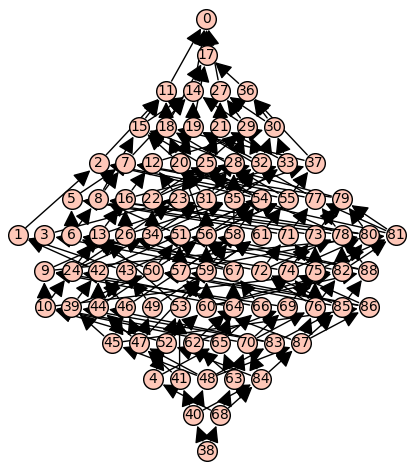

In [92]:
right_lifting_classes_poset.plot()

In [114]:
cov_rels = right_lifting_classes_poset.cover_relations()
heights = {k : 0 for k in range(n_right_lifting_classes)}

changed = True
while changed:
    changed = False
    for (a,b) in cov_rels:
        if heights[b] <= heights[a]:
            heights[b] = heights[a] + 1
            changed = True

max_height = max(heights.values())

of_height = {k : [i for i in range(n_right_lifting_classes) if heights[i] == k] for k in set(heights.values())}
coords = dict()
for h in range(max_height + 1):
    level = of_height[h]
    width = len(level)
    for i, k in enumerate(level):
        xcoord = 2*i - width + 1
        coords[k] = (xcoord, h)

print("\\begin{tikzpicture}[scale=3.5]")

for k,name in enumerate(right_lifting_classes_names):
    print(f"\\node ({k}) at {coords[k]} {{${name}$}};")

for (a,b) in cov_rels:
	print(f"\\draw[white,ultra thick,double=black,arrows={{-Triangle[black,scale=0.25]}}] ({a}) -- ({b});")

print("\\end{tikzpicture}")

\begin{tikzpicture}[scale=3.5]
\node (0) at (0, 12) {$\all$};
\node (1) at (-14, 6) {$\surj^e$};
\node (2) at (-8, 8) {$(\surj^e) \cup \init^e$};
\node (3) at (-12, 6) {$\inj^e$};
\node (4) at (-4, 2) {$(\inj^e \cap \surj^e) \cup \init^e$};
\node (5) at (-10, 7) {$\surj^{C_p}$};
\node (6) at (-10, 6) {$(\surj^e \cap \surj^{C_p}) \cup \{\id_\varnothing\}^{C_p}$};
\node (7) at (-6, 8) {$(\surj^{C_p}) \cup \init^e \cup \{\id_\varnothing\}^{C_p}$};
\node (8) at (-8, 7) {$(\surj^e \cap \surj^{C_p}) \cup \init^e \cup \{\id_\varnothing\}^{C_p}$};
\node (9) at (-12, 5) {$(\inj^e \cap \surj^{C_p}) \cup \init^e \cup \{\id_\varnothing\}^{C_p}$};
\node (10) at (-12, 4) {$(\inj^e \cap \surj^e) \cup \init^e \cup \{\id_\varnothing\}^{C_p}$};
\node (11) at (-3, 10) {$(\surj^e) \cup \init^{C_p}$};
\node (12) at (-4, 8) {$(\inj^e) \cup \init^{C_p}$};
\node (13) at (-8, 6) {$(\inj^e \cap \surj^e) \cup \init^{C_p}$};
\node (14) at (-1, 10) {$(\surj^{C_p}) \cup \init^{C_p}$};
\node (15) at (-5, 9) {$(\surj

In [118]:
len(right_lifting_classes_poset.relations())

1777